# Inferencia RAD-ALERT
Este notebook toma el dataset limpio (`data_cleaned.xlsx`), prepara el texto concatenando y normalizando las columnas relevantes,
ejecuta la inferencia con el modelo RAD-ALERT, y exporta el conjunto de datos de los reportes "Críticos" para entrenamiento.


In [1]:
from dotenv import load_dotenv
import os

load_dotenv()  # carga automáticamente el .env de la raíz

DATA_DIR           = os.getenv("DATA_DIR", "./data")
RAW_DATA_PATH      = os.getenv("RAW_DATA_PATH", "./data/raw/dataset.xlsx")
PROCESSED_DATA_PATH= os.getenv("PROCESSED_DATA_PATH", "./data/processed/dataset_procesado.pkl")
MODELS_DIR         = os.getenv("MODELS_DIR", "./models")
RANDOM_SEED        = int(os.getenv("RANDOM_SEED", 42))

In [ ]:
# Ajuste liviano de versiones (evita reinstalar torch, que consume mucha RAM)
%pip install --upgrade --no-cache-dir "tokenizers==0.20.3" "transformers==4.46.3" Unidecode

In [3]:
import pandas as pd
import re
from unidecode import unidecode
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Configurar modelo RAD-ALERT
# La ruta se toma del archivo .env (variable MODELS_DIR) o de ./models como fallback.
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_path = Path(MODELS_DIR)  # cargado desde .env en la celda 0
print(f"Ruta modelo: {model_path}")
print(f"Existe ruta: {model_path.exists()}")

try:
    if not model_path.exists():
        raise FileNotFoundError(f"No existe la ruta del modelo: {model_path}")

    tokenizer = AutoTokenizer.from_pretrained(str(model_path), local_files_only=True)
    model = AutoModelForSequenceClassification.from_pretrained(str(model_path), local_files_only=True)

    # Forzamos CPU para evitar errores de memoria en GPU
    device = torch.device('cpu')
    model.to(device)
    model.eval()
    print(f"Modelo cargado correctamente en {device}.")
except Exception as e:
    print(f"Error al cargar el modelo: {e}")
    print("Verifica la ruta en .env (variable MODELS_DIR) y que la carpeta tenga config.json, tokenizer y model.safetensors.")


In [ ]:
# Configurar modelo RAD-ALERT
# La ruta se toma del archivo .env (variable MODELS_DIR) o de ../models como fallback.
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_path = Path(MODELS_DIR)  # cargado desde .env en la celda 0
print(f"Ruta modelo: {model_path}")
print(f"Existe ruta: {model_path.exists()}")

try:
    if not model_path.exists():
        raise FileNotFoundError(f"No existe la ruta del modelo: {model_path}")

    tokenizer = AutoTokenizer.from_pretrained(str(model_path), local_files_only=True)
    model = AutoModelForSequenceClassification.from_pretrained(str(model_path), local_files_only=True)

    # Forzamos CPU para evitar errores de memoria en GPU
    device = torch.device('cpu')
    model.to(device)
    model.eval()
    print(f"Modelo cargado correctamente en {device}.")
except Exception as e:
    print(f"Error al cargar el modelo: {e}")
    print("Verifica la ruta en .env (variable MODELS_DIR) y que la carpeta tenga config.json, tokenizer y model.safetensors.")


In [ ]:
# Función para predecir
def predict_critical(text):
    if not text.strip():
        return "No crítico", 0.0
        
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512, padding=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        # Ajusta el índice (1 o 0) según qué clase represente 'Crítico' en tu modelo
        prob_critico = probs[0][1].item() 
        
    pred = "Crítico" if prob_critico >= 0.5 else "No crítico"
    return pred, prob_critico

# Aplicar a todo el dataset
# Descomenta las siguientes líneas cuando el modelo esté configurado:
print("Iniciando inferencia...")
df['rad_prediccion'], df['rad_score'] = zip(*df['texto_normalizado'].apply(predict_critical))
print(df['rad_prediccion'].value_counts())


Iniciando inferencia...
rad_prediccion
No crítico    3025
Crítico        952
Name: count, dtype: int64


In [ ]:
# Filtrar y Exportar
# Descomenta esto después de ejecutar la inferencia exitosamente.

df_criticos = df[df['rad_prediccion'] == 'Crítico'].copy()
print(f"Total de registros Críticos identificados por RAD-ALERT: {len(df_criticos)}")

# Guardar el dataset final como rad_criticos.xlsx
df_criticos.to_excel('../data/rad_criticos.xlsx', index=False)
print("Exportado exitosamente a '../data/rad_criticos.xlsx'")


Total de registros Críticos identificados por RAD-ALERT: 952
Exportado exitosamente a '../data/rad_criticos.xlsx'


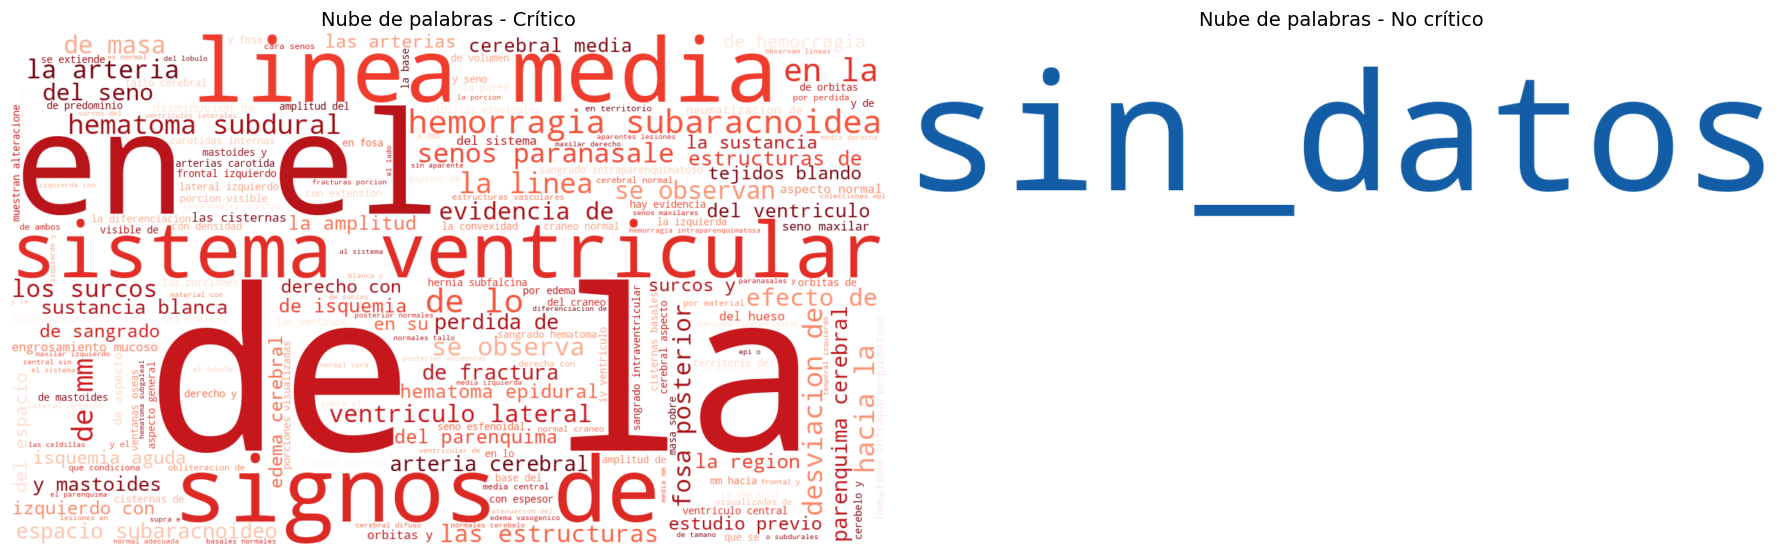

In [ ]:
# Nubes de palabras por clase usando columnas: texto_normalizado y rad_prediccion
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Cambia esta ruta por tu archivo Excel
ruta_excel = '../data/rad_criticos.xlsx'

df_wc = pd.read_excel(ruta_excel)

# Validar columnas requeridas
columnas_requeridas = {'texto_normalizado', 'rad_prediccion'}
faltantes = columnas_requeridas - set(df_wc.columns)
if faltantes:
    raise ValueError(f"Faltan columnas en el Excel: {faltantes}")

# Asegurar tipos
df_wc['texto_normalizado'] = df_wc['texto_normalizado'].fillna('').astype(str)
df_wc['rad_prediccion'] = df_wc['rad_prediccion'].fillna('').astype(str).str.strip()

# Separar textos por clase
texto_critico = ' '.join(df_wc.loc[df_wc['rad_prediccion'].str.lower() == 'crítico', 'texto_normalizado'])
texto_no_critico = ' '.join(df_wc.loc[df_wc['rad_prediccion'].str.lower() == 'no crítico', 'texto_normalizado'])

# Evitar error si una clase no tiene texto
if not texto_critico.strip():
    texto_critico = 'sin_datos'
if not texto_no_critico.strip():
    texto_no_critico = 'sin_datos'

# Crear nubes
wc_critico = WordCloud(width=1200, height=700, background_color='white', colormap='Reds').generate(texto_critico)
wc_no_critico = WordCloud(width=1200, height=700, background_color='white', colormap='Blues').generate(texto_no_critico)

# Mostrar ambas en una figura
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(wc_critico, interpolation='bilinear')
axes[0].set_title('Nube de palabras - Crítico', fontsize=14)
axes[0].axis('off')

axes[1].imshow(wc_no_critico, interpolation='bilinear')
axes[1].set_title('Nube de palabras - No crítico', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()